# Practica para flujo de fluidos incompresibles

In [2]:
import numpy as np

## Ecuación de Shacham para el calculo del factor de Darcy de flujo en tuberías:

$$
f_D = \left[-2 \log\left(\frac{\frac{\epsilon}{D}}{3.71}-\frac{5.02}{\mathrm{Re}}\log\left(\frac{\frac{\epsilon}{D}}{3.71}+\frac{14.5}{\mathrm{Re}}\right)\right)\right]^{-2}
$$

## Método de las 2k de Hooper para calcular K de accesorio

$$
K = \frac{K_1}{Re} + K_{\infty} (1 + \frac{1}{D_i})
$$

In [6]:
def calculo_Fd(rugosidad, D_interno, Reynolds):
    proporcion = rugosidad / D_interno
    
    A = ((proporcion/3.71)+(14.5/Reynolds))
    B = (5.02/Reynolds) * np.log10(A)
    C = (proporcion/3.71) - B
    D = -2 * np.log10(C)
    Fd = D**(-2)
    
    return Fd


def calculo_k_2k(D_interno, Reynolds, k1, kinf):
    A = 1 + (1/D_interno)
    B = kinf * A
    K = (k1/Reynolds) + B
    
    return K    

### 1) Considere el punto 1 de una tubería donde la presión absoluta es de 5 atm, ubicado a 250 m de un punto 2 de la misma tubería donde la presión absoluta es de 3 atm. Si no existen diferencias sustanciales en las alturas entre estos dos puntos para el glicerol ($\rho_{glicerol} = 1260$ kg/m³ aprox).

### Responda brevemente.¿Cuánto son las pérdidas totales en este tramo de tubería si el fluido fluye del punto 1 al punto 2? (No hay cambio de fase, y es fludo newtoniano)

Suposiciones:

- No hay cambio de energía potencial.
- No hay cambio de energía cinética, ya que en el tramo no hay cambio de area, no indican fluido que acelera.
- El fluido es incompresible, no hay cambio significativo de densidad en el glicerol.
- No hay Potencia de impulso, por lo tanto el termino $\dot{W} = 0$

In [4]:
P_1 = 5
P_2 = 3
delta_P = - (P_2 - P_1)         # atm
delta_P = delta_P * (101325)    # Pa
den = 1260                      # kg/m³
print(f'Cambio de presión : {delta_P} Pa')

perdidas_flujo = (delta_P/den) * 2

print(f'Perdidas de energía por flujo : {perdidas_flujo:,.4f} J / Kg')
print(f'Perdidas de energía por flujo : {perdidas_flujo/1000:,.4f} kJ / Kg')

Cambio de presión : 202650 Pa
Perdidas de energía por flujo : 321.6667 J / Kg
Perdidas de energía por flujo : 0.3217 kJ / Kg


### 2) En una unidad de la planta de producción de ácido fumárico se necesita reparar la tubería de acero inoxidable 316 que conduce la solución acuosa de ácido maléico desde el tanque de preparación de la solución hasta el reactor de isomerización por un tramo de 20 metros en total. Como ingeniero de planta se le pide elegir el tipo de material adecuado para hacer la reparación entre los disponibles en el proveedor de confianza presentes en la siguiente tabla. Justifique con al menos dos motivos.


| Material             | Diametro         | Longitud  | Peso        | Rugosidad  | Precio              |
| -------------------- | ---------------- | --------- | ----------- | ---------- | ------------------- |
| PVC                  | 21mm             | 6m/tubo   | 1kg/tubo    | 1.5 micron | $ 30.000 COP / tubo |
| Polietileno          | 25mm             | 25m/rollo | 5.75kg/tubo | NA         | $ 80.000 COP/ rollo |
| Acero Inoxidable 316 | DN 1 inch sch 40 | 6m/tubo   | NA          | 45 micron  | 240 USD / tubo      |
| Vidrio               | 8mm              | 2m/tubo   | NA          | 1.5 micron | 300 USD / tubo      |


si 1 USD = 3500 COP (2026/04)

240USD = 840.000 COP
300USD = 1.050.000 COP

### Aspectos a analizar:

- El acido maleico tiende a tener a un valor muy bajo el pH en solución acuosa (pKa1 aprox 1.9), este aspecto se debe tener presente ya que puede causar daños al estar en contacto con distintos materiales
- El ácido maléico a condiciones ambientales se encuentra en estado sólido, por lo tanto se requiere precalentar para solubilizar en agua en temperaturas alrededor de 135°C
- Seguridad industrial: se asume el transito de alta frecuencia de operarios, espacios disponibles para evaluación de desempeño o reparación de segmentos entre equipos de proceso.
- Tiempo de vida util: se debe evaluar con que frecuencia se debe hacer cambio de tuberías por desgaste de herramientas para el flujo. 

### Elementos decisivos

- Se descartan las opciones de PVC y Polietileno, ya que estos funcionan bien para el flujo de fluidos con pH aproximadamente en 7 y a condiciones ambientales (como el agua), porque tienen menor temperatura máxima de servicio, mayor coeficiente de expansión térmica, reducción de módulo mecánico con temperatura aumentando tambien el riesgo de fugas

- Se descarta la opción material de vidrio por que presenta mayor costo en instalación y mantenimiento del material, en logística y manipulación. Poseen baja fragilidad mecánica, es decir baja tenacidad a la fractura, sensible a impactos y vibraciones y fallo súbito (sin daño gradua que permita dar indicios para mantenimiento preventivo), tambien es sensible a realizar adecuaciónes (como incorporar uniones tipo rosca, accesorios, T's)

### Acero Inoxidable 316 :

- Tiene mayor resistencia mecánica, resistiendo altos niveles de T y P, resistencia química para permitir el flujo de fluidos con pH acidos o básicos, sin presentar deformación química, y la frecuencia del mantenimiento es bajo y práctico. Su precio en un inicio puede ser elevado, pero los gastos extraordinarios para reparación, mantenimiento, reposición y adecuación, es bajo frente a las otras opciones, que quizas requieran mayor frecuencia de reposición de materiales que ya alcanzaron la vida util, y la reinstalación es otro gasto considerable.

## Se necesita el siguiente montaje entre la descarga de la bomba que lleva el producto de fermentación desde un bioreactor a través de un filtro para separar la solución de etanol de las levaduras.

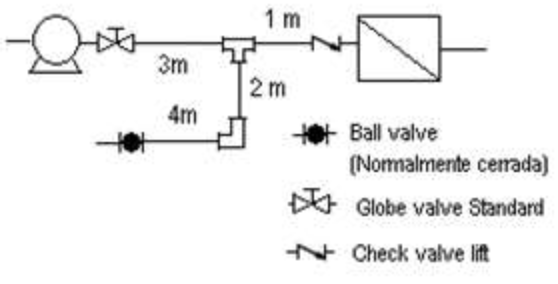

## Se desea garantizar una producción de:
## - 3.15 l/s de solución de etanol (caudal de diseño).
## - (viscosidad cinematica $\nu$ = 1 x 10^-5 m2/s) 

##### 1. Calcule las pérdidas locales y por fricción (longitud) si se sabe que la tubería es de acero inoxidable 316 DN 1 in Sch 40 (rugosidad 45 micron) con accesorios roscados. 
##### 2. Calcule las pérdidas en el filtro si se sabe que es de tipo superficial de 2.5 m2 y que opera a presión constante. Gracias a datos experimentales se sabe que el parámetro de formación de la torta uW/2k es igual a 1 atm*h/m2. 
##### 3. Si la energía entregada por la bomba es de 80 mca, es posible garantizar que sale filtrado a la salida del filtro?

Del catálogo del autor Darby, tomamos la siguiente referencia (acero inoxidable 316 DN 1 in Sch 40)

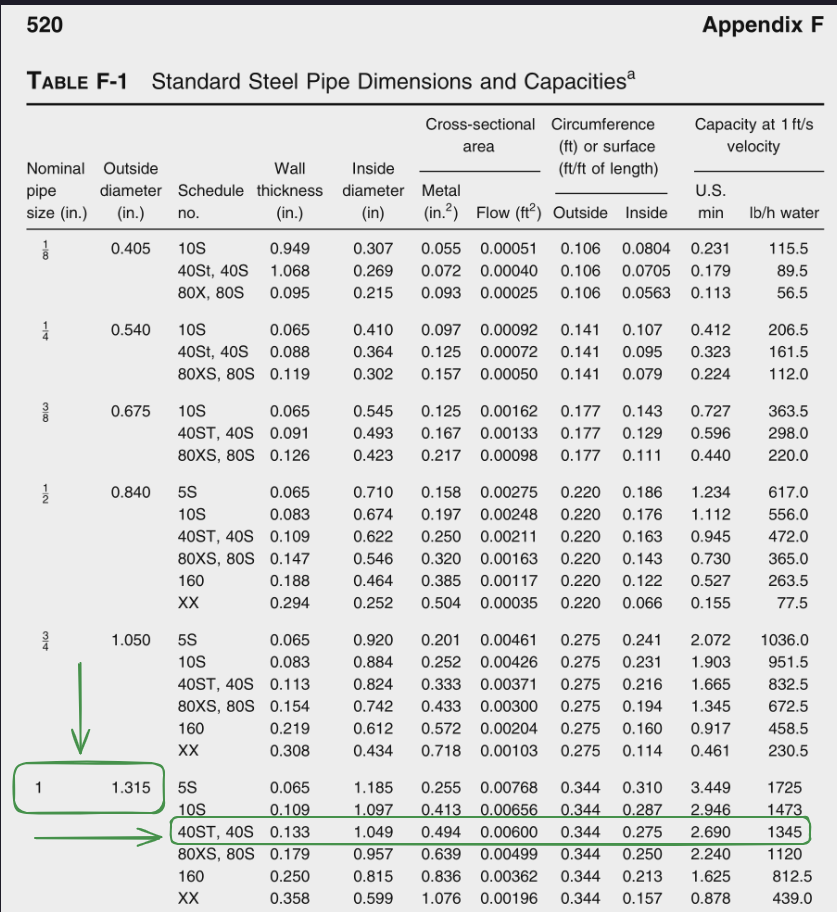

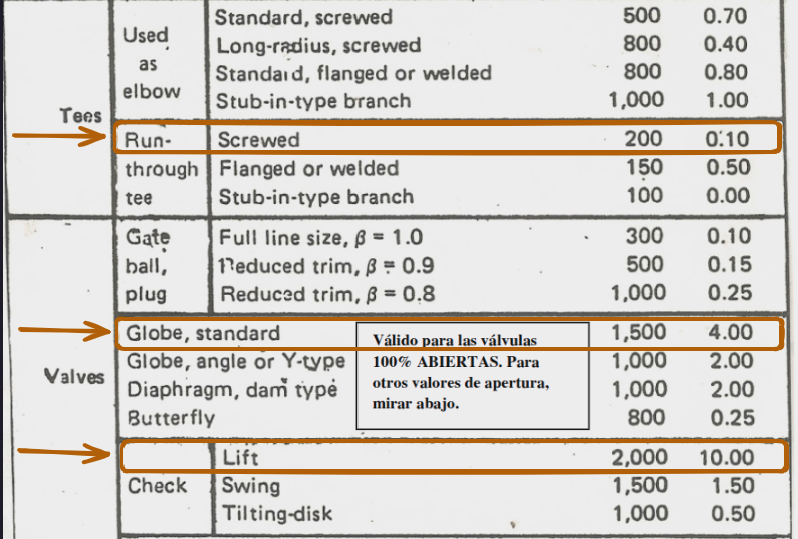

In [ ]:
# Unidades:

g = 9.8                 # gravedad m / s²
visc_cinem = 1e-05      # viscosidad cinematica m² / s
caudal = 3.15 * (1/1000) # caudal m³ / s

#   Detalles tubería:
D_interno = 1.049 * (0.0254)        # diametro interno m
rugosidad = 45 * (1/(1e-06))        # rugodsidad m

#   Calculos :

A_flujo = np.pi * ((D_interno**2)/4)
vel_flujo = caudal / A_flujo

print(f'Area de flujo : {A_flujo:,.4f} m²')
print(f'velocidad de flujo : {vel_flujo:,.4f} m/s')



#   Objetivo 1 : Determinar reynolds para conocer el régimen de flujo:
#   ------------------------------------------------------------------

Reynolds = vel_flujo * D_interno / visc_cinem

print(f'\nNúmero de Reynolds para este régimen : {Reynolds:,.4f} ({Reynolds:,.2e})')
print(f'Al ser mayor a 2400 (Re > 2400), el flujo es turbulento')



#   Objetivo 2  : Perdidas de flujo desde la bomba, punto de descarga, hasta el friltro, se ignora el tramo a partir de la T hasta la valvula de descarga:
#   bomba_descarga ; valv_globo_standard ; L_3m ; T_ ; L_1m ; valv_check
#   ------------------------------------------------------------------------------------------------------------------------------------------------------

#   Sección solo tuberías (L_3m, L_1m):
#   el factor de darcy solo es funcion de propiedades de flujo y area de flujo de tubería.

fd_AI_DN1_SCH40 = calculo_Fd(rugosidad, D_interno, Reynolds)

h_L_3m = (3/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40
h_L_1m = (1/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40

#   Sección accesorios y valvulas (bomba_descarga ; valv_globo_standard ; T_ ; valv_check):
#   Para efectos prácticos, se usara el método de las 2k

k1_valv_globo_standard = 1500 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_globo_standard = 4  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_globo_standard = calculo_k_2k(D_interno, Reynolds, k1_valv_globo_standard, kinf_valv_globo_standard)

k1_T_ = 200 # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
kinf_T_ = 0.1  # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
K_T_ = calculo_k_2k(D_interno, Reynolds, k1_T_, kinf_T_)

k1_valv_check_lift = 2000 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_check_lift = 10  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_check_lift = calculo_k_2k(D_interno, Reynolds, k1_valv_check_lift, kinf_valv_check_lift)

h_valv_globo_standard = K_valv_globo_standard * ((vel_flujo**2)/2)
h_T_ = K_T_ * ((vel_flujo**2)/2)
h_valv_check_lift = K_valv_check_lift * ((vel_flujo**2)/2)

#   Calculamos h_total:

h_total = h_L_3m + h_L_1m + h_valv_globo_standard + h_T_ + h_valv_check_lift

print(f'perdidas locales total : {h_total:,.4f} J/kg')
print(f'perdidas locales total : {h_total/1000:,.2f} kJ/kg')


#   Objetivo 3 : Perdidas en el filtro
# 2.5 m2
# delta_P = 0 
# uW/2k es igual a 1 atm*h/m2
# se usa la relación delta_P = C * (Q/A) donde C es una constante uW/2k que es un parametro de operación del filtro

delta_P_filtro = 1 * vel_flujo
print(delta_P_filtro)


Area de flujo : 0.0006 m²
velocidad de flujo : 5.6494 m/s

Número de Reynolds para este régimen : 15,052.5981 (1.51e+04)
Al ser mayor a 2400 (Re > 2400), el flujo es turbulento
perdidas locales total : 8,681.6217 J/kg
perdidas locales total : 8.68 kJ/kg
5.649399183005517
